In [1]:
import pandas as pd
import numpy as np

#sep=r"\s+" means r-raw string,s-white space,+-one or more---overall means seperate whenever u see one or more white space
df=pd.read_csv("german.data",sep=r"\s+",header=None)
#header=None describes that the starting row is not to be treated as header as we dont have headings like Name,Amount etc 
#python automactially sees the first row as header 

df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [2]:
df.shape


(1000, 21)

In [3]:
df.info


<bound method DataFrame.info of       0   1    2    3     4    5    6   7    8     9   ...    11  12    13  \
0    A11   6  A34  A43  1169  A65  A75   4  A93  A101  ...  A121  67  A143   
1    A12  48  A32  A43  5951  A61  A73   2  A92  A101  ...  A121  22  A143   
2    A14  12  A34  A46  2096  A61  A74   2  A93  A101  ...  A121  49  A143   
3    A11  42  A32  A42  7882  A61  A74   2  A93  A103  ...  A122  45  A143   
4    A11  24  A33  A40  4870  A61  A73   3  A93  A101  ...  A124  53  A143   
..   ...  ..  ...  ...   ...  ...  ...  ..  ...   ...  ...   ...  ..   ...   
995  A14  12  A32  A42  1736  A61  A74   3  A92  A101  ...  A121  31  A143   
996  A11  30  A32  A41  3857  A61  A73   4  A91  A101  ...  A122  40  A143   
997  A14  12  A32  A43   804  A61  A75   4  A93  A101  ...  A123  38  A143   
998  A11  45  A32  A43  1845  A61  A73   4  A93  A101  ...  A124  23  A143   
999  A12  45  A34  A41  4576  A62  A71   3  A93  A101  ...  A123  27  A143   

       14 15    16 17    18    

In [4]:
df.describe()

,1,4,7,10,12,15,17,20
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [5]:
df[20].value_counts()
#take 20 column values as it descibes good or bad using 1 and 2 numbers respectively
#value_counts()-takes unique elements and gives its count

#we see this to see if good and bad is distributed properly 
#if good=950 and bad=50 then the model might give always good

#Observation:

#70% of customers are Good Credit and 30% are Bad Credit.
#The dataset is somewhat imbalanced but not severely.

20
1    700
2    300
Name: count, dtype: int64

In [6]:
columns=["checking_account","duration","credit_history","purpose","credit_amount","savings","employment",
         "installment_rate","personal_status_sex","other_debtors","residence_since","property","age",
         "other_installment_plans","housing","existing_credits","job","dependents","telephone",
         "foreign_worker","target"]

df.columns=columns

df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [7]:
#checking for missing values in each column
df.isnull().sum()

checking_account           0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings                    0
employment                 0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
dependents                 0
telephone                  0
foreign_worker             0
target                     0
dtype: int64

In [8]:
#divide the columns into numerical and categorical 
#we can know by printing df.info() if Dtype=object then categorical else numerical

df.info()

categorical_cols=df.select_dtypes(include="object").columns
numerical_cols=df.select_dtypes(include=["int64","float64"]).columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment               1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [9]:
print("Categorical columns: ")
print(categorical_cols)

print("\nNumerical columns")
print(numerical_cols)

Categorical columns: 
Index(['checking_account', 'credit_history', 'purpose', 'savings',
       'employment', 'personal_status_sex', 'other_debtors', 'property',
       'other_installment_plans', 'housing', 'job', 'telephone',
       'foreign_worker'],
      dtype='object')

Numerical columns
Index(['duration', 'credit_amount', 'installment_rate', 'residence_since',
       'age', 'existing_credits', 'dependents', 'target'],
      dtype='object')


In [10]:
df[numerical_cols].describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [11]:
df["housing"].value_counts()

housing
A152    713
A151    179
A153    108
Name: count, dtype: int64

In [12]:
df.groupby("target")["credit_amount"].mean()

#Observation:
#Bad credit customers tend to borrow larger loan amounts.
#This suggests credit amount may be an important predictor.

target
1    2985.457143
2    3938.126667
Name: credit_amount, dtype: float64

In [13]:
pd.crosstab(df["savings"], df["target"])

target,1,2
savings,,
A61,386,217
A62,69,34
A63,52,11
A64,42,6
A65,151,32


In [14]:
df.groupby("target")["age"].mean()

target
1    36.224286
2    33.963333
Name: age, dtype: float64

In [15]:
df.duplicated().sum()

0

<Axes: >

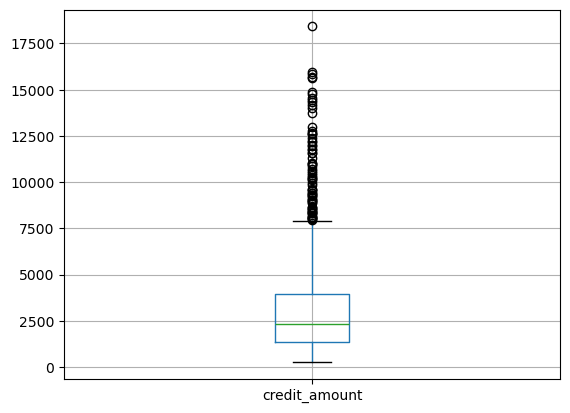

In [16]:
df.boxplot(column="credit_amount")

In [17]:
df[numerical_cols].corr()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,target
duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834,0.214927
credit_amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142,0.154739
installment_rate,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207,0.072404
residence_since,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643,0.002967
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201,-0.091127
existing_credits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667,-0.045732
dependents,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000,-0.003015
target,0.214927,0.154739,0.072404,0.002967,-0.091127,-0.045732,-0.003015,1.000000


In [18]:
#Numerical Features vs Target

#1 CREDIT AMOUNT

df.groupby("target")["credit_amount"].mean()

#1-Good customer--AVG = 2985.457143
#2-Bad customer--AVG = 3938.126667

#Observation:
#Bad credit customers tend to have larger loan amounts.

target
1    2985.457143
2    3938.126667
Name: credit_amount, dtype: float64

In [19]:
#2 DURATION

df.groupby("target")["duration"].mean()

#BAD>GOOD DURATION

#Observation
#Bad customers tend to have more duration of loans

target
1    19.207143
2    24.860000
Name: duration, dtype: float64

In [20]:
#3 AGE

df.groupby("target")["age"].mean()

#Observation:
# credit are slightly younger on average (33.96 years) compared to customers with good credit (36.22 years).

#However, the difference is relatively small (~2.3 years), suggesting age alone may not be a strong predictor of credit risk.

target
1    36.224286
2    33.963333
Name: age, dtype: float64

In [21]:
#CATEGORICAL FEATURES VS TARGET

#4 CHECKING ACCOUNT

pd.crosstab(df["checking_account"], df["target"])

#A11 = balance < 0 DM
#A12 = balance 0–200 DM
#A13 = balance >= 200 DM
#A14 = no checking account

#Observation:
#- A11 has a high proportion of bad credit customers.
#- A13 has very few bad credit customers.
#- Better checking account status is associated with lower credit risk.
#- Checking account status appears to be an important predictor.

target,1,2
checking_account,,
A11,139,135
A12,164,105
A13,49,14
A14,348,46


In [22]:
#5 SAVINGS

pd.crosstab(df["savings"], df["target"])

#A61 = Savings < 100 DM
#A62 = Savings 100–500 DM
#A63 = Savings 500–1000 DM
#A64 = Savings ≥ 1000 DM
#A65 = Unknown / No Savings Account

# Observation:
# - A61 has the highest number of bad credit customers.
# - Bad credit cases decrease as savings increase.
# - A64 has very few bad credit customers.
# - Higher savings are associated with lower credit risk.
# - Savings status appears to be an important predictor.

target,1,2
savings,,
A61,386,217
A62,69,34
A63,52,11
A64,42,6
A65,151,32


In [23]:
#6 EMPLOYMENT

pd.crosstab(df["employment"], df["target"])

# A71 = Unemployed
# A72 = < 1 year employment
# A73 = 1–4 years employment
# A74 = 4–7 years employment
# A75 = ≥ 7 years employment

# Observation:
# - A71 (Unemployed) has a relatively high proportion of bad credit customers.
# - A75 (≥ 7 years employment) has fewer bad credit customers.
# - Customers with longer employment history tend to have lower credit risk.
# - Employment stability appears to be an important predictor.

target,1,2
employment,,
A71,39,23
A72,102,70
A73,235,104
A74,135,39
A75,189,64


In [24]:
#Check duplicates

df.duplicated().sum()

0

In [25]:
df[numerical_cols].describe()

# Observation:
# - Average loan duration is 20.9 months.
# - Average credit amount is 3271 DM.
# - Average customer age is 35.5 years.
# - Most customers have only 1 existing credit.
# - Most customers have 1 dependent.
# - Credit amounts vary widely (250 DM to 18424 DM).
# - Loan durations range from 4 to 72 months.
# - Customer ages range from 19 to 75 years.

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [26]:
#Converting 
#Current 1=Good,2=Bad to ----- 0=Good,1=Bad

df["target"] = df["target"].map({1: 0, 2: 1})

In [27]:
X = df.drop("target", axis=1)
y = df["target"]



In [28]:
X = pd.get_dummies(X, drop_first=True)
X

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,checking_account_A12,checking_account_A13,checking_account_A14,...,property_A124,other_installment_plans_A142,other_installment_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,False,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,True,False,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,False,False,True,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,False,False,False,...,True,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,False,False,True,...,False,False,True,True,False,True,False,False,False,False
996,30,3857,4,4,40,1,1,False,False,False,...,False,False,True,True,False,False,False,True,True,False
997,12,804,4,4,38,1,1,False,False,True,...,False,False,True,True,False,False,True,False,False,False
998,45,1845,4,4,23,1,1,False,False,False,...,True,False,True,False,True,False,True,False,True,False


In [29]:
#Verifying Target
y.value_counts()

target
0    700
1    300
Name: count, dtype: int64

In [40]:
#Split Training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [42]:
#logistic Regression-MODEL 1

from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000)

model.fit(X_train_scaled,y_train)

#model.fit(X_train,y_train)

#U get this (ConvergenceWarning: lbfgs failed to converge (status=1):
#STOP: TOTAL NO. of ITERATIONS REACHED LIMI)because features are of different scales:
# age              -> 20 to 75
# credit_amount    -> 250 to 18424
# duration         -> 4 to 72

#Logistic Regression works better when features are scaled.

LogisticRegression(max_iter=1000)

In [43]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

y_pred = model.predict(X_test_scaled)

accuracy_score(y_test, y_pred)

0.795

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


### Logistic Regression Results

# - Model achieved 79.5% accuracy on the test set.
# - Correctly identified 124 good credit customers and 35 bad credit customers.
# - Recall for bad credit customers was 59%.
# - The model performs reasonably well as a baseline but misses some high-risk customers.
# - Further improvement may be possible using more advanced models such as Random Forest or XGBoost.

Accuracy: 0.795

Confusion Matrix:
[[124  17]
 [ 24  35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       141
           1       0.67      0.59      0.63        59

    accuracy                           0.80       200
   macro avg       0.76      0.74      0.74       200
weighted avg       0.79      0.80      0.79       200



In [45]:
#RANDOM FOREST-MODEL 2

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)


In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

### Random Forest Results

# - Accuracy decreased from 79.5% to 75%.
# - Recall for bad credit customers decreased from 59% to 36%.
# - The model missed more high-risk customers than Logistic Regression.
# - Logistic Regression performed better for this dataset and remains the preferred baseline model.

Accuracy: 0.75
[[129  12]
 [ 38  21]]
              precision    recall  f1-score   support

           0       0.77      0.91      0.84       141
           1       0.64      0.36      0.46        59

    accuracy                           0.75       200
   macro avg       0.70      0.64      0.65       200
weighted avg       0.73      0.75      0.73       200



In [47]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)
Note: you may need to restart the kernel to use updated packages.


In [51]:
from xgboost import XGBClassifier

xgb=XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train,y_train)

y_pred_xgb=xgb.predict(X_test)


In [52]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

### Model Comparison

# | Model | Accuracy | Recall (Bad Credit) |
# |---------|---------|---------|
# | Logistic Regression | 79.5% | 59% |
# | Random Forest | 75.0% | 36% |
# | XGBoost | 78.5% | 46% |

# Observations:
# - Logistic Regression achieved the best overall performance.
# - Random Forest had the lowest recall for bad credit customers.
# - XGBoost improved over Random Forest but did not outperform Logistic Regression.
# - Logistic Regression was selected as the final model for this project.

Accuracy: 0.785
[[130  11]
 [ 32  27]]
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       141
           1       0.71      0.46      0.56        59

    accuracy                           0.79       200
   macro avg       0.76      0.69      0.71       200
weighted avg       0.78      0.79      0.77       200



In [54]:
import joblib

joblib.dump(model, "credit_risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [55]:
loaded_model = joblib.load("credit_risk_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")